# Terrorism Hotspots — EDA
## Context
 Analyze the data and draw conclusions on the distribution and nature of terrorist incidents recorded around the world
## Data Source
Global Terrorism Database (GTD) — https://www.start.umd.edu/gtd/
## Questions to answer
1. How has the number of terrorist activities changed over the years?
2. Are there certain regions where this trend is different from the global averages?
3. Is the number of incidents and the number of casualties correlated?
4. Can you spot any irregularities or outliers?
5. What are the most common methods of attacks? Does it differ in various regions or in time?
6. Plot the locations of attacks on a map to visualize their regional spread;
## Notebook Structure
1. Data Loading & Understanding
2. Data Cleaning
3. EDA — Temporal trends
4. EDA — Incidents vs Casualties
5. EDA — Attack methods
6. Geo visualization
7. Key Insights & Recommendations


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.helpers import describe_missing, fmt_axis, fit_ols
from pathlib import Path

## 1. Load & Inspect

In [28]:
df = pd.read_csv("../data/raw/globalterrorismdb_0718dist.tar.bz2", compression="bz2")
df.info()
df.describe()


C:\Users\Olha\AppData\Local\Temp\ipykernel_23672\2436467889.py:1: DtypeWarning: Columns (5: approxdate, 7: resolution, 32: attacktype2_txt, 34: attacktype3_txt, 62: gsubname2, 63: gname3, 64: gsubname3, 77: claimmode2_txt, 80: claimmode3_txt, 91: weaptype3_txt, 93: weapsubtype3_txt, 95: weaptype4_txt, 97: weapsubtype4_txt, 115: divert, 116: kidhijcountry, 122: ransomnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/globalterrorismdb_0718dist.tar.bz2", compression="bz2")


<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 136 entries, Unnamed: 0 to related
dtypes: float64(55), int64(23), str(58)
memory usage: 188.5 MB


,Unnamed: 0,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,181691.000000,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,90845.000000,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,52449.818217,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,0.000000,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,45422.500000,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,90845.000000,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,136267.500000,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,181690.000000,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


## Reframe & Inspect

In [29]:
subset_cols = ["iyear", "imonth", "country_txt", "region_txt", "city", "latitude",
               "longitude","success", "suicide", "attacktype1", "attacktype1_txt",
               "targtype1_txt", "targsubtype1_txt", "target1", "natlty1_txt", "gname",
               "gsubname", "nperps", "weaptype1_txt", "weapsubtype1_txt", "nkill", "nkillus"]
df_subset = df[subset_cols]
df_subset.info()
df_subset.describe()


<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   iyear             181691 non-null  int64  
 1   imonth            181691 non-null  int64  
 2   country_txt       181691 non-null  str    
 3   region_txt        181691 non-null  str    
 4   city              181256 non-null  str    
 5   latitude          177135 non-null  float64
 6   longitude         177134 non-null  float64
 7   success           181691 non-null  int64  
 8   suicide           181691 non-null  int64  
 9   attacktype1       181691 non-null  int64  
 10  attacktype1_txt   181691 non-null  str    
 11  targtype1_txt     181691 non-null  str    
 12  targsubtype1_txt  171318 non-null  str    
 13  target1           181053 non-null  str    
 14  natlty1_txt       180132 non-null  str    
 15  gname             181691 non-null  str    
 16  gsubname          5890 non-null

,iyear,imonth,latitude,longitude,success,suicide,attacktype1,nperps,nkill,nkillus
count,181691.000000,181691.000000,177135.000000,1.771340e+05,181691.000000,181691.000000,181691.000000,110576.000000,171378.000000,117245.000000
mean,2002.638997,6.467277,23.498343,-4.586957e+02,0.889598,0.036507,3.247547,-65.361154,2.403272,0.045981
std,13.259430,3.388303,18.569242,2.047790e+05,0.313391,0.187549,1.915772,216.536633,11.545741,5.681854
min,1970.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,1.000000,-99.000000,0.000000,0.000000
25%,1991.000000,4.000000,11.510046,4.545640e+00,1.000000,0.000000,2.000000,-99.000000,0.000000,0.000000
50%,2009.000000,6.000000,31.467463,4.324651e+01,1.000000,0.000000,3.000000,-99.000000,0.000000,0.000000
75%,2014.000000,9.000000,34.685087,6.871033e+01,1.000000,0.000000,3.000000,1.000000,2.000000,0.000000
max,2017.000000,12.000000,74.633553,1.793667e+02,1.000000,1.000000,9.000000,25000.000000,1570.000000,1360.000000


### From description, we can assume:
1. Columns `longitude`, `latitude`, `city`, `nperps`, `nkill` should be inspected for nan and unpredictable values.
2. Column `nkill` need to be inspected for outliers.

In [30]:
print(df_subset.isna().sum())
print(df_subset.duplicated().sum())

iyear                    0
imonth                   0
country_txt              0
region_txt               0
city                   435
latitude              4556
longitude             4557
success                  0
suicide                  0
attacktype1              0
attacktype1_txt          0
targtype1_txt            0
targsubtype1_txt     10373
target1                638
natlty1_txt           1559
gname                    0
gsubname            175801
nperps               71115
weaptype1_txt            0
weapsubtype1_txt     20768
nkill                10313
nkillus              64446
dtype: int64
12921


In [31]:
short_check_cols = ["iyear", "attacktype1_txt", "nkill", "success", "targtype1_txt", "nperps", "country_txt", "city"]

nan_coord = describe_missing(df_subset,
                             df_subset["latitude"].isna() | df_subset["longitude"].isna(),
                             "Missing coordinates",
                             short_check_cols)


Missing coordinates: 2.51% of dataset, 94.89% successful attacks rate, 47.83% with fatal casualties among successful
     iyear              attacktype1_txt  nkill  success  \
16    1970                      Unknown    1.0        1   
103   1970  Hostage Taking (Kidnapping)    0.0        0   
132   1970  Hostage Taking (Kidnapping)    0.0        1   
165   1970  Hostage Taking (Kidnapping)    0.0        1   
210   1970            Bombing/Explosion   36.0        1   

               targtype1_txt  nperps  country_txt     city  
16                  Military     1.0     Ethiopia  Unknown  
103     Government (General)     3.0        Spain  Unknown  
132      Journalists & Media     NaN     Ethiopia  Unknown  
165  Government (Diplomatic)     NaN     Ethiopia  Unknown  
210      Airports & Aircraft     NaN  Philippines  Cauayan  


Coordinates are not used to analyze trends over the years or the correlation between incidents and casualties; therefore, rows containing `NaN` for `lat/long` are fully valid here, and it was decided not to exclude them from the analysis.
However, to plot the locations of attacks on a map to visualize their regional spread, rows without coordinates cannot physically be plotted on the map; therefore, excluding them for this task is a technical necessity.


In [32]:
print(df_subset["latitude"].describe())
print(df_subset["longitude"].describe())
print(df_subset[df_subset["longitude"] < -180])
null_island = df_subset[(df_subset["latitude"] == 0) & (df_subset["longitude"] == 0)]
print(len(null_island))

count    177135.000000
mean         23.498343
std          18.569242
min         -53.154613
25%          11.510046
50%          31.467463
75%          34.685087
max          74.633553
Name: latitude, dtype: float64
count    1.771340e+05
mean    -4.586957e+02
std      2.047790e+05
min     -8.618590e+07
25%      4.545640e+00
50%      4.324651e+01
75%      6.871033e+01
max      1.793667e+02
Name: longitude, dtype: float64
       iyear  imonth country_txt                   region_txt  \
17658   1982      12   Nicaragua  Central America & Caribbean   

                   city   latitude   longitude  success  suicide  attacktype1  \
17658  Valle El Oregano  12.643985 -86185896.0        1        0            2   

       ... targsubtype1_txt             target1 natlty1_txt    gname gsubname  \
17658  ...   Other Facility  tour of El Oregano   Nicaragua  Contras      NaN   

      nperps weaptype1_txt                   weapsubtype1_txt nkill nkillus  
17658    NaN      Firearms  Automatic or S

An abnormally large value for `longitude` was found in the description; upon checking, it turned out to be a typographical error — a missing decimal point. The coordinates fall within the actual range for the relevant country if the longitude value is divided by `1,000,000`.

In [33]:
df_subset["iyear"].unique()

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1986, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1990, 1991,
       1992, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017])

In [34]:
df_subset["imonth"].unique()
unknown_month = describe_missing(
    df_subset,
    df_subset["imonth"] == 0,
    "Unknown month",
    short_check_cols)
unknown_month[short_check_cols]

Unknown month: 0.01% of dataset, 95.00% successful attacks rate, 5.26% with fatal casualties among successful
      iyear              attacktype1_txt  nkill  success  \
1      1970  Hostage Taking (Kidnapping)    0.0        1   
1123   1972            Bombing/Explosion    0.0        1   
1690   1973  Hostage Taking (Kidnapping)    0.0        1   
2164   1974            Bombing/Explosion    0.0        0   
2165   1974            Bombing/Explosion    0.0        1   

                targtype1_txt  nperps  country_txt         city  
1     Government (Diplomatic)     7.0       Mexico  Mexico city  
1123      Airports & Aircraft     NaN  Philippines        Roxas  
1690                 Business     NaN     Colombia      unknown  
2164                 Business     NaN       France        Paris  
2165      Airports & Aircraft     NaN        Italy         Rome  


,iyear,attacktype1_txt,nkill,success,targtype1_txt,nperps,country_txt,city
1,1970,Hostage Taking (Kidnapping),0.0,1,Government (Diplomatic),7.0,Mexico,Mexico city
1123,1972,Bombing/Explosion,0.0,1,Airports & Aircraft,NaN,Philippines,Roxas
1690,1973,Hostage Taking (Kidnapping),0.0,1,Business,NaN,Colombia,unknown
2164,1974,Bombing/Explosion,0.0,0,Business,NaN,France,Paris
2165,1974,Bombing/Explosion,0.0,1,Airports & Aircraft,NaN,Italy,Rome
2744,1975,Bombing/Explosion,NaN,1,Airports & Aircraft,NaN,Pakistan,Rawalpindi
3484,1976,Unknown,NaN,1,Military,NaN,Turkey,Istanbul
3485,1976,Unknown,NaN,1,Military,NaN,Turkey,Ankara
4407,1977,Bombing/Explosion,NaN,1,Educational Institution,NaN,Japan,Tokyo
4408,1977,Bombing/Explosion,NaN,1,Business,NaN,Japan,Tokyo


Less than 1% of `imonth` entries contain the sentinel value `0`, which the GTD uses as a coding convention for unknown month. Most of these records have missing information about casualties (`0` or `NaN`), so cannot be analyzed. During data cleaning these values are mapped to `NaN`; the rows stay in `df_clean`, so Q1/Q2 (yearly counts) are unaffected, and they are excluded only from the monthly analysis in Q3.

In [35]:
df_subset["region_txt"].unique()

<StringArray>
['Central America & Caribbean',               'North America',
              'Southeast Asia',              'Western Europe',
                   'East Asia',               'South America',
              'Eastern Europe',          'Sub-Saharan Africa',
  'Middle East & North Africa',       'Australasia & Oceania',
                  'South Asia',                'Central Asia']
Length: 12, dtype: str

In [36]:
nan_kills = describe_missing(df_subset,
                             df_subset["nkill"].isna(),
                             "Missing information about number of fatalities",
                             check_fatal=False)

Missing information about number of fatalities: 5.68% of dataset, 96.10% successful attacks rate
    iyear                 attacktype1_txt  nkill  success  \
3    1970               Bombing/Explosion    NaN        1   
4    1970  Facility/Infrastructure Attack    NaN        1   
15   1970               Bombing/Explosion    NaN        1   
34   1970  Facility/Infrastructure Attack    NaN        1   
95   1970                   Armed Assault    NaN        1   

              targtype1_txt  nperps         country_txt  
3   Government (Diplomatic)     NaN              Greece  
4   Government (Diplomatic)     NaN               Japan  
15     Government (General)     NaN  East Germany (GDR)  
34                   Police     NaN  East Germany (GDR)  
95                 Tourists     NaN              Jordan  


Almost `5.7%` of the `nkill` records contain no information. Following further investigation, it can be assumed that this is not due to an error during data collection. It is most likely that a terrorist attack took place, but no precise figures on the number of fatalities have been recorded. It was therefore decided to isolate a subset of the data and analyse it separately.

In [37]:
print(df_subset["nkill"].quantile([0.5, 0.9, 0.95, 0.99]))
q_99 = df_subset["nkill"].quantile( 0.99)
outliers =  df_subset[df_subset["nkill"] > q_99]
print(outliers[short_check_cols].sort_values("nkill").tail(10))
outliers_success_rate = outliers["success"].sum() / len(outliers) * 100
print(outliers_success_rate)

0.50     0.0
0.90     5.0
0.95    10.0
0.99    31.0
Name: nkill, dtype: float64
        iyear              attacktype1_txt   nkill  success  \
170198   2016  Hostage Taking (Kidnapping)   433.0        1   
136746   2014  Hostage Taking (Kidnapping)   517.0        1   
76347    2004                Armed Assault   518.0        1   
179671   2017            Bombing/Explosion   588.0        1   
133225   2014                Armed Assault   670.0        1   
136283   2014  Hostage Taking (Kidnapping)   953.0        1   
55934    1994                Armed Assault  1180.0        1   
73127    2001                    Hijacking  1383.0        1   
73126    2001                    Hijacking  1384.0        1   
133518   2014  Hostage Taking (Kidnapping)  1570.0        1   

                      targtype1_txt  nperps    country_txt              city  
170198  Private Citizens & Property   -99.0          Syria           Palmyra  
136746                     Military   -99.0          Syria          

Unlike the missing-value checks above, this outlier analysis is run once against a fixed threshold (q99) and isn't reused across other columns, so it wasn't abstracted into describe_missing/a shared helper — the added indirection wouldn't pay for itself for a single call site.
`1%` of events are characterised by a significantly higher number of fatalities than in most of the data. These records will be analysed separately as `high_impact_incidents`. The data includes both well-documented historical events (for example, presumably records of the aircraft hijackings on 11 September 2001) and cases where classification by attack type may not fully reflect the complexity of the incident.

In [38]:
print(df_subset["attacktype1_txt"].unique())
unknown_attacktype = describe_missing(df_subset,
                                      df_subset["attacktype1_txt"] == "Unknown",
                                      "Unknown attack type")


<StringArray>
[                      'Assassination',         'Hostage Taking (Kidnapping)',
                   'Bombing/Explosion',      'Facility/Infrastructure Attack',
                       'Armed Assault',                           'Hijacking',
                             'Unknown',                     'Unarmed Assault',
 'Hostage Taking (Barricade Incident)']
Length: 9, dtype: str
Unknown attack type: 4.00% of dataset, 82.67% successful attacks rate, 64.02% with fatal casualties among successful
     iyear attacktype1_txt  nkill  success targtype1_txt  nperps  country_txt
16    1970         Unknown    1.0        1      Military     1.0     Ethiopia
39    1970         Unknown    0.0        0      Military     NaN  Philippines
150   1970         Unknown    1.0        1      Military     NaN  Philippines
169   1970         Unknown    2.0        1      Military     NaN  Philippines
328   1970         Unknown    0.0        0      Military     NaN       Jordan


Unclassified attack vectors represent 4% of total entries. Given an 83% success rate within this group and a 64.02% fatality rate among those successes, these records were kept in the main dataset rather than dropped. This has no effect on Q1/Q2 (temporal trends) or Q3 (incidents vs casualties), since none of them uses `attacktype1_txt`; it will, however, appear as its own category in Q5 (attack methods by region/time) and should be interpreted as "method not recorded," not as a distinct attack type.

In [39]:
nan_perps = describe_missing(df_subset,
                             df_subset["nperps"].isna(),
                             "Missing number of terrorists participating in the incident")

Missing number of terrorists participating in the incident: 39.14% of dataset, 92.63% successful attacks rate, 41.53% with fatal casualties among successful
    iyear                 attacktype1_txt  nkill  success  \
0    1970                   Assassination    1.0        1   
2    1970                   Assassination    1.0        1   
3    1970               Bombing/Explosion    NaN        1   
4    1970  Facility/Infrastructure Attack    NaN        1   
10   1970               Bombing/Explosion    0.0        0   

                  targtype1_txt  nperps         country_txt  
0   Private Citizens & Property     NaN  Dominican Republic  
2           Journalists & Media     NaN         Philippines  
3       Government (Diplomatic)     NaN              Greece  
4       Government (Diplomatic)     NaN               Japan  
10                     Military     NaN       United States  


The majority of records missing the `nperps` feature were successful attacks. Unrecorded perpetrator numbers are a well-documented domain pattern in real-world conflict data. These values are not participating in any future calculations, so it will stay in dataset .

In [40]:
sentinel_nperps = describe_missing(df_subset,
                                   df_subset["nperps"] == -99,
                                   "Sentinel value of terrorists participating in the incident")

Sentinel value of terrorists participating in the incident: 45.25% of dataset, 86.63% successful attacks rate, 51.60% with fatal casualties among successful
    iyear                 attacktype1_txt  nkill  success  \
5    1970                   Armed Assault    0.0        1   
7    1970               Bombing/Explosion    0.0        1   
11   1970  Facility/Infrastructure Attack    0.0        1   
13   1970  Facility/Infrastructure Attack    0.0        1   
14   1970  Facility/Infrastructure Attack    0.0        1   

           targtype1_txt  nperps    country_txt  
5                 Police   -99.0  United States  
7              Utilities   -99.0  United States  
11              Military   -99.0  United States  
13  Government (General)   -99.0  United States  
14              Business   -99.0  United States  


Approximately 45% of `nperps` entries contain the sentinel value `-99`, which the GTD uses as a coding convention for unknown values rather than representing a numerical anomaly. These records will be retained. During the data cleaning phase, all `-99` values will be mapped to `NaN`.

## Data Understanding: Key Findings & Action Plan
#### Geospatial Data (`lat/long`):
 Missing coordinates will be kept for general analysis, but excluded only for map plotting. A typographical scaling error in `longitude` was identified and will be corrected during data cleaning.
#### Date (`imonth`):
`0.01%` contain the GTD sentinel value `0` (unknown month). It is mapped to `NaN`; the rows are kept for yearly analysis and excluded only from the monthly analysis.
#### Casualties (`nkill`):
Missing values (`~5.7%`) reflect real-world reporting gaps and will be analyzed separately. Extreme outliers (top `1%`) will be isolated as `high_impact_incidents`.
#### Attack Types:
 Unclassified vectors (`4%`) will remain in the main dataset — they don't affect Q1–Q3, which don't use `attacktype1_txt`, but will appear as their own category in Q5 and should be read as "method not recorded," not a distinct attack type.
#### Perpetrators (`nperps`):
Not used in Q1–Q3. The GTD sentinel value `-99` (`~45%` of entries) is mapped to `NaN`, so `nperps` is `NaN` in `~84%` of rows.

## Data Cleaning

In [41]:
df_clean = df_subset.copy()

mask_lon = df_clean["longitude"] < -180
df_clean.loc[mask_lon, "longitude"] = df_clean.loc[mask_lon, "longitude"] / 1_000_000

df_clean["nperps"] = df_clean["nperps"].replace(-99, np.nan)

df_clean.loc[df_clean["imonth"] == 0, "imonth"] = np.nan

assert len(df_clean) == len(df_subset)
print(len(df_clean))
print(df_clean["longitude"].between(-180, 180).sum() + df_clean["longitude"].isna().sum() == len(df_clean))
print(df_clean["nperps"].isna().sum(), df_clean["imonth"].isna().sum())

181691
True
153333 20


Cleaning steps (row count unchanged, 181,691):
- `longitude` values below −180 divided by `1,000,000` (decimal-point error, verified against the codebook);
- `nperps == -99` mapped to `NaN` (GTD sentinel for unknown), 153,333 `NaN` in total;
- `imonth == 0` mapped to `NaN` (unknown month), 20 rows.

In [42]:
df_clean.dtypes

iyear                 int64
imonth              float64
country_txt             str
region_txt              str
city                    str
latitude            float64
longitude           float64
success               int64
suicide               int64
attacktype1           int64
attacktype1_txt         str
targtype1_txt           str
targsubtype1_txt        str
target1                 str
natlty1_txt             str
gname                   str
gsubname                str
nperps              float64
weaptype1_txt           str
weapsubtype1_txt        str
nkill               float64
nkillus             float64
dtype: object

# EDA — Temporal Trends
1. How has the number of terrorist activities changed over the years?
2. Are there certain regions where this trend is different from the global averages?

In [43]:
from cycler import cycler

BG, FG, ACCENT = "#16181a", "#a0aab2", "#4355f7"

def set_theme():
    sns.set_theme(style="dark", rc={
        "figure.dpi": 150,
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "text.color": FG,
        "axes.labelcolor": FG,
        "axes.titlecolor": "white",
        "xtick.color": FG,
        "ytick.color": FG,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.left": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#ffffff",
        "grid.alpha": 0.2,
        "grid.linestyle": "--",
        "axes.prop_cycle": cycler(color=[ACCENT, "#4dc3ff", "#ffd24d", "#7dff4d"]),
    })

set_theme()

Created global theme for figures

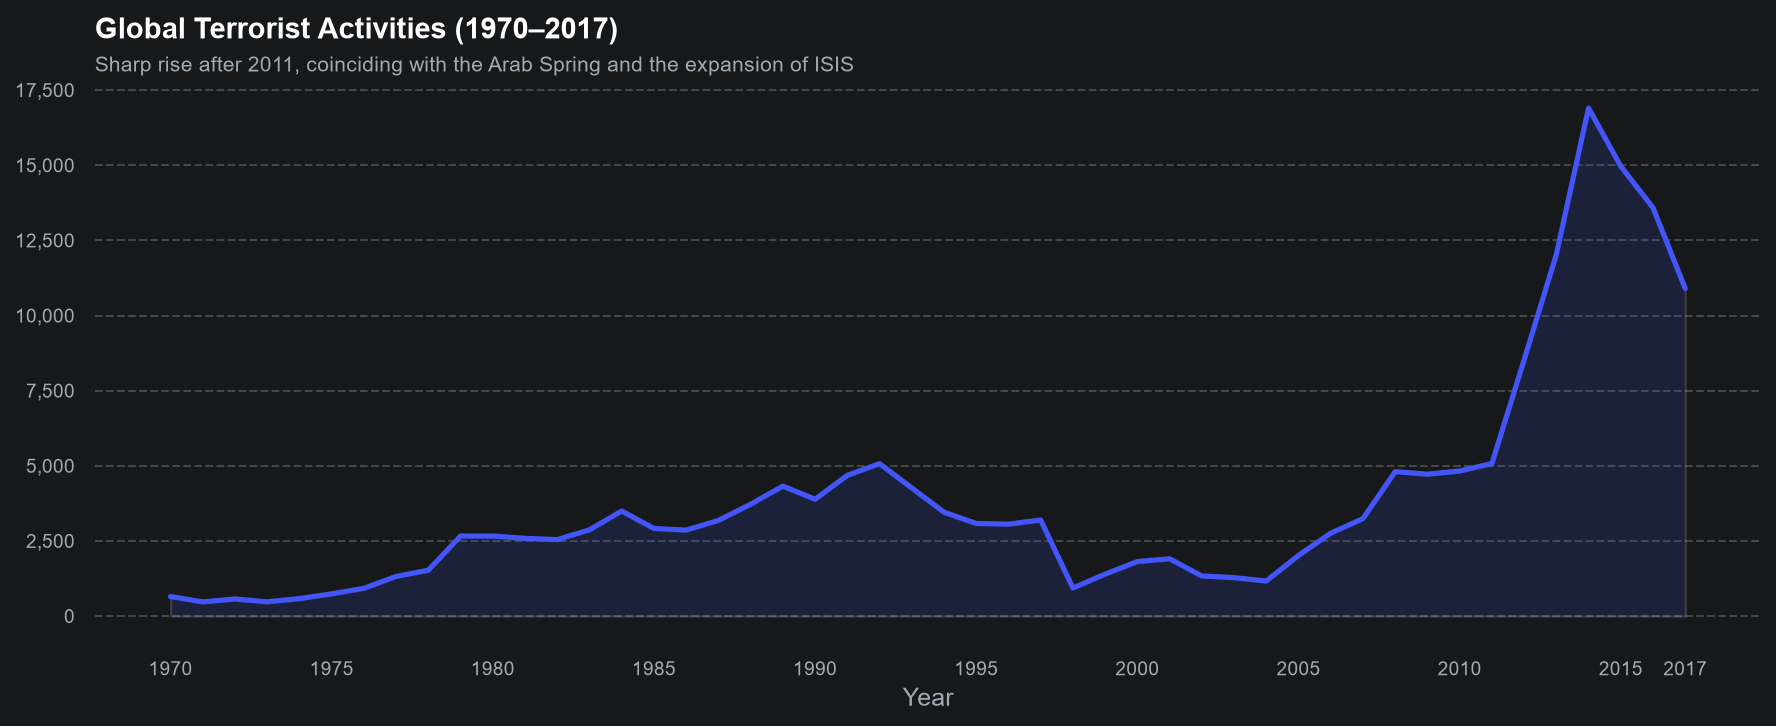

In [44]:
global_trend = df_clean.groupby("iyear").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(global_trend["iyear"], global_trend["count"], linewidth=2.5)
ax.fill_between(global_trend["iyear"], global_trend["count"], alpha=0.15)
plt.title(
    "Global Terrorist Activities (1970–2017)\n", fontsize=14, fontweight="bold", loc="left"
)
ax.text(
    0, 1.02, "Sharp rise after 2011, coinciding with the Arab Spring and the expansion of ISIS",
    transform=ax.transAxes, color="#a0aab2", fontsize=10
)
ax.set_xlabel("Year")
ax.set_ylabel("")
years = list(
    range(global_trend["iyear"].min(), global_trend["iyear"].max(), 5)
    ) + [global_trend["iyear"].max()]
ax.set_xticks(years)
fmt_axis(ax)

plt.tight_layout()

output_dir =  Path("..") / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "Global Terrorist Activities (1970–2017).png", dpi=300)
plt.show()


When analyzing global trend of terrorist activities within years we can see sharp increase in recorded incidents after 2011, which is linked with the historical events.

In [45]:
region_trend = df_clean.groupby(["iyear", "region_txt"]).size().reset_index(name="count")
top4 = region_trend.groupby("region_txt")["count"].sum().nlargest(4).index
region_trend["region_group"] = region_trend["region_txt"].where(region_trend["region_txt"].isin(top4), "Other")

wide = region_trend.groupby(["iyear", "region_group"])["count"].sum().unstack(fill_value=0)
order = wide.drop(columns="Other").sum().sort_values(ascending=False).index.tolist() + ["Other"]
wide = wide[order]

groups = {
    "MENA + South Asia": ["Middle East & North Africa", "South Asia"],
    "South America + Other": ["South America", "Other"],
}

total = wide.sum(axis=1)
shares = pd.DataFrame({
    name: wide[cols].sum(axis=1) / total * 100
    for name, cols in groups.items()
}).round(1)

shares.loc[1995:]


,MENA + South Asia,South America + Other
iyear,,
1995,53.3,39.0
1996,36.4,56.5
1997,32.5,58.8
1998,41.0,49.7
1999,38.8,51.0
2000,34.7,54.8
2001,39.2,52.3
2002,49.5,41.4
2003,51.9,42.4


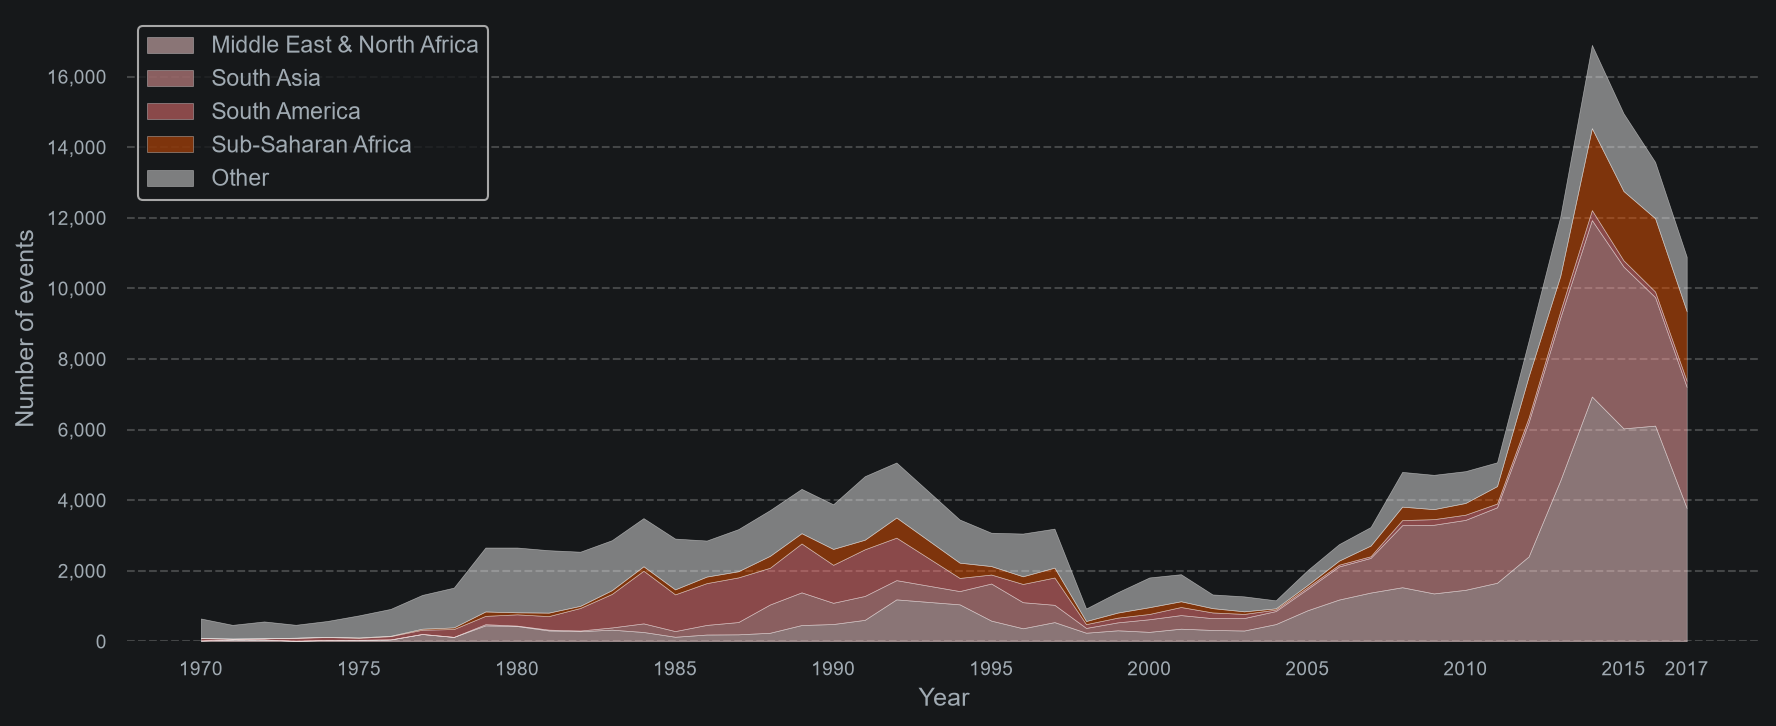

In [46]:
colors = ["#ffd2d2", "#ffa6a6", "#ff7a7a", "#e65100", "#E5E5E5"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(wide.index, wide.T.values, labels=wide.columns, colors=colors, alpha=0.5, edgecolor="#ffffff", linewidth=0.3)
ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.legend(loc="upper left")
ax.set_xticks(years)
fmt_axis(ax)

plt.tight_layout()
fig.savefig(output_dir / "Terrorist Activities within regions(1970–2017).png", dpi=300)
plt.show()

### Conclusion
Regional aggregation shows that the geography of recorded terrorism shifted sharply in 2004, not after the post-2011 surge. Between 1995 and 2003, Middle East & North Africa and South Asia together accounted for 32.5–53.3% of incidents;; from 2004 their combined share jumped to 74% and stayed between 66% and 77% through 2017. The surge after 2011 therefore increased the volume of incidents within an already concentrated geography rather than changing it: the combined share was 71% in 2010 and 75% in 2011, and 66–76% in 2012–2017. Before 2004 the distribution was more fragmented: South America and the lower-volume regions grouped as "Other" held 39–59% of incidents in 1995–2003, versus no more than 24% from 2004 onward.

# EDA — Incidents vs Casualties
Is the number of incidents and the number of casualties correlated?

In [47]:
df_corr = df_clean[df_clean["nkill"].notna() & ~df_clean["nkill"].isin(outliers["nkill"])]
df_corr = df_corr.dropna(subset=["imonth"]).copy()
df_corr["imonth"] = df_corr["imonth"].astype(int)

Created `df_corr` — records with a known `nkill` that are not extreme outliers (above q99). This is a separate variable so that `df_clean`, used in the temporal analysis, stays unchanged. All results below describe "typical" incidents, not the whole dataset. Rows with unknown month (`imonth` = NaN) are also dropped here (9 incidents with known `nkill`). Together with the `nkill` filter, this makes the yearly counts in Q3 lower than the Q1 counts, which use all of `df_clean`.

In [48]:
yearly = (
    df_corr.groupby("iyear")
    .agg(count=("nkill", "size"), nkill_sum=("nkill", "sum"))
    .reindex(range(1970, 2018))
)
yearly["mean_nkill"] = yearly["nkill_sum"] / yearly["count"]

Aggregated incidents by year: number of incidents (`count`), total fatalities (`nkill_sum`) and average fatalities per incident (`mean_nkill`). The index is reindexed to the full range 1970–2017, so the year 1993, which has no records, appears as `NaN` instead of being silently skipped.

In [49]:
monthly = (
    df_corr.groupby(["iyear", "imonth"])
    .agg(attacks_this_month=("nkill", "size"), nkill_sum=("nkill", "sum"))
)
full_index = pd.MultiIndex.from_product(
    [range(1970, 2018), range(1, 13)], names=["iyear", "imonth"]
)
monthly = monthly.reindex(full_index)
in_data = monthly.index.get_level_values("iyear").isin(df_corr["iyear"].unique())
monthly.loc[in_data] = monthly.loc[in_data].fillna(0)
monthly["mean_nkill"] = monthly["nkill_sum"] / monthly["attacks_this_month"]

Built the same monthly table over a complete calendar (every year × month). Months with no incidents inside years that have data are filled with `0`; `mean_nkill` is `NaN` for months without incidents, because the average is undefined there.

In [50]:
print(yearly[["count", "nkill_sum", "mean_nkill"]].corr(method="spearman"))

res_year_sum = fit_ols(yearly, "nkill_sum", "count")
res_year_mean = fit_ols(yearly, "mean_nkill", "count")
res_year_sum_diff = fit_ols(yearly.diff(), "nkill_sum", "count")
res_year_mean_diff = fit_ols(yearly.diff(), "mean_nkill", "count")
df_corr["nkill"].mean()

               count  nkill_sum  mean_nkill
count       1.000000   0.936055    0.168478
nkill_sum   0.936055   1.000000    0.416512
mean_nkill  0.168478   0.416512    1.000000
n = 47
                            OLS Regression Results                            
Dep. Variable:              nkill_sum   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     1034.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.08e-32
Time:                        19:19:25   Log-Likelihood:                -407.25
No. Observations:                  47   AIC:                             818.5
Df Residuals:                      45   BIC:                             822.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    st

np.float64(1.7464204485192736)

Spearman rank correlation is used as a first look at the relationships, because the distribution of fatalities is heavily skewed and Pearson correlation is sensitive to extreme values.
Yearly regressions:
- `nkill_sum ~ count` answers the question directly: is the number of incidents related to the number of fatalities? Note that the relationship is partly built in: total fatalities = number of incidents × average fatalities per incident.
- `mean_nkill ~ count` removes this built-in link and asks whether incidents become deadlier when there are more of them.
- The same models on first differences (`diff()`) remove the shared upward trend over time and check whether the relationship holds for year-to-year changes.
### Yearly results
- Total fatalities closely follow the number of incidents: R² = 0.958, about 1.87 additional fatalities per additional incident. The relationship remains strong for year-to-year changes (R² = 0.749, slope 1.83), so it is not only a shared upward trend.
- Part of this link is built in: total fatalities = number of incidents × average fatalities per incident, and the slope is close to that average (about `1.75`).
- Average fatalities per incident are not related to the number of incidents (levels: R² = 0.026, p = 0.278; changes: R² = 0.031, p = 0.247).
- Caveats: low Durbin-Watson values in the level models (0.73 and 0.39) mean the residuals are autocorrelated, so p-values are too optimistic; residuals of the differenced model are heavy-tailed (kurtosis 7.5). Results describe incidents with known `nkill` up to 31 (extreme outliers excluded); 1993 is missing from the data.

In [51]:
res_m_sum = fit_ols(monthly, "nkill_sum", "attacks_this_month")
res_m_mean = fit_ols(monthly, "mean_nkill", "attacks_this_month")
res_m_sum_diff = fit_ols(monthly.diff(), "nkill_sum", "attacks_this_month")
res_m_mean_diff = fit_ols(monthly.diff(), "mean_nkill", "attacks_this_month")

n = 564
                            OLS Regression Results                            
Dep. Variable:              nkill_sum   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     6217.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          4.55e-306
Time:                        19:19:25   Log-Likelihood:                -3696.0
No. Observations:                 564   AIC:                             7396.
Df Residuals:                     562   BIC:                             7405.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -27.346

The same four models on monthly data. The predictor is the number of incidents in the same month as the outcome, so both cover the same period. This gives more observations, but consecutive months are similar, so autocorrelation is stronger and p-values should be treated with caution.
### Monthly results
- Total fatalities again follow the number of incidents: R² = 0.917, about 1.84 fatalities per additional incident, so part of this link is built in. For month-to-month changes the relationship is weaker (R² = 0.298, slope 1.07), because single months are dominated by a few very deadly incidents (heavy-tailed residuals, kurtosis 7.2).
- Average fatalities per incident are not related to the number of incidents in the same month (R² = 0.006, p = 0.065). For month-to-month changes a weak negative association appears (R² = 0.131, slope −0.0026, p < 0.001): months with more incidents than the previous month tend to have slightly lower average fatalities per incident. This is probably partly a ratio effect, because the average is calculated from the same count used as the predictor.
- Caveats: Durbin-Watson values far from 2 (0.59 and 0.86 for levels, 2.88 and 3.01 for differences) mean autocorrelated residuals, so p-values are not reliable. Values near 3 on differences are a typical side effect of differencing.

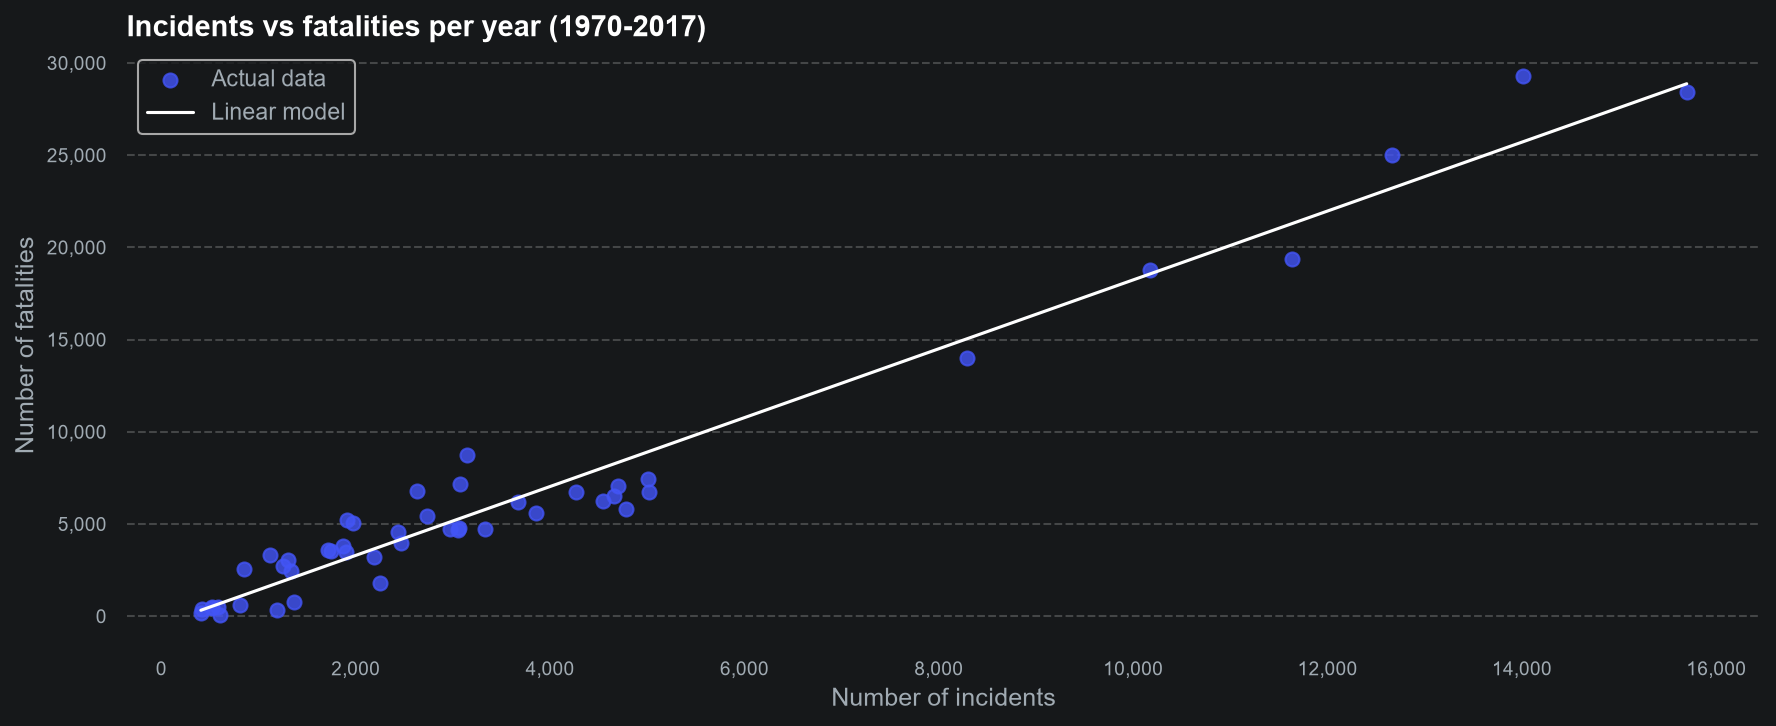

In [52]:
d = yearly.dropna(subset=["count", "nkill_sum"])
xs = np.linspace(d["count"].min(), d["count"].max(), 100)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(d["count"], d["nkill_sum"], alpha=0.8, s=45, label="Actual data")
ax.plot(xs, res_year_sum.params["const"] + res_year_sum.params["count"] * xs,
        color="#ffffff", label="Linear model")
ax.set_xlabel("Number of incidents")
ax.set_ylabel("Number of fatalities")
ax.set_title("Incidents vs fatalities per year (1970-2017)", loc="left", fontsize=14, fontweight="bold")
ax.legend()
fmt_axis(ax, axis="x")
fmt_axis(ax, axis="y")
plt.tight_layout()
fig.savefig(output_dir / "Linear model.png", dpi=300)
plt.show()

Scatter plot of yearly incidents against yearly fatalities with the fitted linear model from the first yearly regression. The line is drawn from the model coefficients, so it does not depend on the row order of the data.

### Conclusion
Incidents and fatalities are strongly correlated in total (yearly R² = 0.958, monthly R² = 0.917), but this is largely expected: total fatalities equal the number of incidents multiplied by the average fatalities per incident. The average lethality of an incident is essentially independent of how many incidents occur (levels: yearly R² = 0.026, monthly R² = 0.006). A weak negative association appears only for month-to-month changes (R² = 0.131), and it is probably partly a ratio effect. All results describe incidents with known `nkill` up to 31, and should be read with the autocorrelation and heavy-tail caveats above.